# KAN Verification Functions

In [25]:
import numpy as np
from src.custom_fastkan import FastKAN, FastKANLayer
import gurobipy as gp
from gurobipy import GRB
import torch
from torch import nn
import time
import torch.optim as optim

def fit_line_through_points(x1, y1, x2, y2):
    slope = (y2 - y1) / (x2 - x1)
    intercept = y1 - slope * x1
    return slope, intercept

def find_all_bspline_segments(layer, input_index, output_index, max_segments):
    n_samples = 25
    # Fetch curve data ONCE
    x_tensor, y_tensor = layer.plot_curve(input_index, output_index, num_pts=n_samples)
    x_points, y_points = x_tensor.detach().cpu().numpy(), y_tensor.detach().cpu().numpy()
    
    # 1. Precompute errors for all possible segments (ONCE)
    errors = np.full((n_samples, n_samples), np.inf)
    for start_idx in range(n_samples-1):
        x_start = x_points[start_idx]
        y_start = y_points[start_idx]
        for end_idx in range(start_idx + 1, n_samples):
            x_end = x_points[end_idx]
            y_end = y_points[end_idx]
            slope, intercept = fit_line_through_points(x_start, y_start, x_end, y_end)
            segment_x = x_points[start_idx:end_idx+1]
            segment_y = y_points[start_idx:end_idx+1]
            predicted_y = slope * segment_x + intercept
            segment_error = np.max(np.abs(predicted_y - segment_y))
            errors[start_idx, end_idx] = segment_error
    
    # 2. Dynamic programming to find optimal segmentation (ONCE)
    dp_table = np.full((max_segments, n_samples), np.inf)
    backtrack = np.zeros((max_segments, n_samples), dtype=int)
    
    # Base Case: 1 segment
    for j in range(1, n_samples):
        dp_table[0, j] = errors[0, j]
    
    # Recurrence
    for i in range(1, max_segments):
        for j in range(i+1, n_samples):
            # We try breaking at k, where k is between the start of this segment number and current point
            # k is the END of the previous segment
            for k in range(i, j): 
                if dp_table[i-1, k] == np.inf: continue
                if errors[k, j] == np.inf: continue
                
                curr_error = max(dp_table[i-1, k], errors[k, j])
                if curr_error < dp_table[i, j]:
                    dp_table[i, j] = curr_error
                    backtrack[i, j] = k

    # 3. Extract results for EVERY segment count from 1 to max_segments
    results = {}
    
    for seg_count in range(1, max_segments + 1):
        row_idx = seg_count - 1
        final_error = dp_table[row_idx, n_samples-1]
        
        # If optimization failed for this count, skip or return infinity
        if final_error == np.inf:
            results[seg_count] = ([], np.inf)
            continue

        # Reconstruct segments for this specific count using the backtrack table
        segments = []
        curr_seg_end = n_samples - 1
        
        for i in range(row_idx, -1, -1):
            if i > 0:
                prev_seg_end = backtrack[i, curr_seg_end]
            else:
                prev_seg_end = 0
            
            x1, y1 = x_points[prev_seg_end], y_points[prev_seg_end]
            x2, y2 = x_points[curr_seg_end], y_points[curr_seg_end]
            slope, intercept = fit_line_through_points(x1, y1, x2, y2)
            segments.insert(0, (x1, x2, slope, intercept))
            
            curr_seg_end = prev_seg_end
        
        results[seg_count] = (segments, final_error)
        
    return results

def calculate_bspline_lipschitz_constant(layer: 'FastKANLayer', input_idx: int, output_idx: int, num_pts: int = 1000, min_x: float = None, max_x: float = None) -> float:
    if min_x is None:
        min_x = layer.rbf.grid_min
    if max_x is None:
        max_x = layer.rbf.grid_max
    x_tensor, y_tensor = layer.plot_curve(input_idx, output_idx, num_pts=num_pts)
    x_np = x_tensor.detach().cpu().numpy()
    y_np = y_tensor.detach().cpu().numpy()
    mask = (x_np >= min_x) & (x_np <= max_x)
    x_np = x_np[mask]
    y_np = y_np[mask]

    dx = np.diff(x_np)
    dy = np.diff(y_np)
    nonzero_dx = dx != 0
    slopes = np.zeros_like(dx)
    slopes[nonzero_dx] = dy[nonzero_dx] / dx[nonzero_dx]
    lipschitz_constant = np.max(np.abs(slopes))
    return lipschitz_constant

def compute_dp_tables_lipschitz(kan_model, max_segments=15):
    error_tables = {}
    segments_tables = {}
    lipschitz_constants = {}
    
    for layer_idx, layer in enumerate(kan_model.layers):
        input_dim = layer.input_dim
        output_dim = layer.output_dim
        print(f"Analyzing Layer {layer_idx}: {input_dim} inputs -> {output_dim} outputs")
        
        for input_idx in range(input_dim):
            for output_idx in range(output_dim):
                spline_key = (layer_idx, input_idx, output_idx)
                all_results = find_all_bspline_segments(layer, input_idx, output_index=output_idx, max_segments=max_segments)
                
                error_table = {}
                segments_table = {}
                
                for k, (segs, err) in all_results.items():
                    segments_table[k] = segs
                    error_table[k] = err
                lipschitz_constant = calculate_bspline_lipschitz_constant(layer=layer, input_idx=input_idx, output_idx=output_idx)
                
                error_tables[spline_key] = error_table
                segments_tables[spline_key] = segments_table
                lipschitz_constants[spline_key] = lipschitz_constant
    
    return error_tables, segments_tables, lipschitz_constants


def weight_dp_tables_lipschitz(kan_model, error_tables, segments_tables, lipschitz_constants):
    node_sensitivities = {}
    num_layers = len(kan_model.layers)
    
    # Intialize final layer with all 1's
    final_layer = kan_model.layers[num_layers - 1]
    for out_idx in range(final_layer.output_dim):
        node_sensitivities[(num_layers, out_idx)] = 1.0

    # Calculate sensitivity for the inputs of a layer based on the output layer's sensitivities
    layer_idx = num_layers - 1
    while layer_idx >= 0:
        current_layer = kan_model.layers[layer_idx]
        for input_idx in range(current_layer.input_dim):
            sensitivity_sum = 0.0
            for output_idx in range(current_layer.output_dim):
                lipschitz_constant = lipschitz_constants.get((layer_idx, input_idx, output_idx), 0.0)
                child_node_sensitivity = node_sensitivities[(layer_idx + 1, output_idx)]
                sensitivity_sum += lipschitz_constant * child_node_sensitivity
            node_sensitivities[(layer_idx, input_idx)] = sensitivity_sum
        layer_idx -= 1

    # Weight the error table (just do sensitivities * table)
    weighted_error_tables = {}
    for layer_idx, layer in enumerate(kan_model.layers):
        for input_idx in range(layer.input_dim):
            for output_idx in range(layer.output_dim):
                current_bspline_key = (layer_idx, input_idx, output_idx)
                # The error of a spline is added directly to its destination node (output_idx)
                sensitivity_of_current_output_node = node_sensitivities[(layer_idx + 1, output_idx)]
                weighted_table_for_bspline = {}
                for pair in error_tables[current_bspline_key].items():
                    num_segments = pair[0]
                    error = pair[1]
                    weighted_table_for_bspline[num_segments] = error * sensitivity_of_current_output_node
                weighted_error_tables[current_bspline_key] = weighted_table_for_bspline
    return weighted_error_tables


def solve_best_segment_allocation(weighted_error_tables, target_max_error):
    model = gp.Model()
    model.setParam("OutputFlag", 0)
    # Create binary variable x[spline_key, num_segments] for every choice and every spline
    x = {}
    binary_vars_for_splines = {} 
    for spline_key, num_segment_options in weighted_error_tables.items():
        binary_vars_for_splines[spline_key] = []
        for pair in num_segment_options.items():
            k_segments = pair[0]
            error_val = pair[1]
            if np.isinf(error_val):
                continue
            x[(spline_key, k_segments)] = model.addVar(vtype=GRB.BINARY, obj=k_segments)
            binary_vars_for_splines[spline_key].append(x[(spline_key, k_segments)])
    model.update()

    # Make sure we can only pick 1 variable
    for pair in binary_vars_for_splines.items():
        spline_key = pair[0]
        variables = pair[1]
        model.addConstr(gp.quicksum(variables) == 1)
    # Make sure we're under the max error
    total_error_expr = gp.quicksum(weighted_error_tables[s_key][k] * x[(s_key, k)] for s_key, k in x.keys())
    model.addConstr(total_error_expr <= target_max_error)

    # Minimize the total number of segments
    total_segments_expr = gp.quicksum(
        k * x[(s_key, k)] 
        for s_key, k in x.keys()
    )
    model.setObjective(total_segments_expr, GRB.MINIMIZE)

    # Optimize!
    model.optimize()
    optimal_allocation = {}
    if model.status == GRB.OPTIMAL:
        for (spline_key, k_segments), variable in x.items():
            if variable.X > 0.5:
                optimal_allocation[spline_key] = k_segments
        print(f"Optimal allocation found with {model.objVal} segments.")
        return optimal_allocation, model.objVal
    elif model.status == GRB.INFEASIBLE:
        return None, float('inf')
    else:
        return None, float('inf')

def build_kan_milp_model(kan_shape, segments_tables, error_tables, optimal_allocation, x_min_vec, x_max_vec):
    model = gp.Model()
    model.setParam("OutputFlag", 0)
    input_dim = kan_shape[0] 
    all_layer_variables = []

    # Create Input Variables
    current_layer_range_variables = []
    for i in range(input_dim):
        input_range_variable = model.addVar(lb=x_min_vec[i], ub=x_max_vec[i])
        current_layer_range_variables.append(input_range_variable)
    all_layer_variables.append(current_layer_range_variables)

    # Build Hidden Layers Sequentially
    num_transitions = len(kan_shape) - 1 # If shape is [784, 32, 10], we have 2 transitions: 0->1 and 1->2
    for layer_idx in range(num_transitions):
        layer_input_dimension = kan_shape[layer_idx]
        layer_output_dimension = kan_shape[layer_idx + 1]
        
        # Initialize output variables for this layer (by creating our list of inputs to the next layer)
        next_layer_input_ranges = []
        for i in range(layer_output_dimension): 
            next_layer_input_ranges.append(gp.LinExpr()) # ex. layer2_neuron_i = layer1_neuron1 + layer1_neuron2 + ... (linear expression!)
        
        for src_idx in range(layer_input_dimension):
            for dst_idx in range(layer_output_dimension):
                # Extract PWL Points
                num_segs = optimal_allocation[(layer_idx, src_idx, dst_idx)]
                seg_data = segments_tables[(layer_idx, src_idx, dst_idx)][num_segs] # table has all possible segment allocations, only extract the optimal one (num_segs)
                x_pts, y_pts = [], []
                for idx, (x1, x2, slope, intercept) in enumerate(seg_data):
                    x_pts.append(x1)
                    y_pts.append(slope * x1 + intercept)
                    if idx == len(seg_data) - 1: # Add end point of last segment
                        x_pts.append(x2)
                        y_pts.append(slope * x2 + intercept)

                # Create output variable for each bspline (adding in error)
                approx_error = error_tables[(layer_idx, src_idx, dst_idx)][num_segs]
                error_var = model.addVar(lb=-approx_error, ub=approx_error)
                src_var = current_layer_range_variables[src_idx]
                result_var = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY)
                model.addGenConstrPWL(src_var, result_var, x_pts, y_pts) # "The relationship between src_var and result_var must follow the path connected by the dots"
                next_layer_input_ranges[dst_idx] += result_var + error_var # fill in the output linear expressions we defined earlier (for each neuron in the next layer)

        # Create variables for next layer nodes
        next_layer_range_variables = []
        for j in range(layer_output_dimension):
            next_layer_range_variable = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY)
            model.addConstr(next_layer_range_variable == next_layer_input_ranges[j])
            next_layer_range_variables.append(next_layer_range_variable)
        current_layer_range_variables = next_layer_range_variables
        
        all_layer_variables.append(current_layer_range_variables)

    model.update()
    return model, all_layer_variables

def get_spline_bounds(segments, x_min, x_max):
    y_min, y_max = np.inf, -np.inf
    for (sx1, sx2, slope, intercept) in segments:
        # Find the intersection of the segment domain and input domain
        overlap_start = max(sx1, x_min)
        overlap_end = min(sx2, x_max)
        # If they overlap, evaluate the line at the edges
        if overlap_start <= overlap_end:
            val_start = slope * overlap_start + intercept
            val_end = slope * overlap_end + intercept
            y_min = min(y_min, val_start, val_end)
            y_max = max(y_max, val_start, val_end)
    return y_min, y_max


def propagate_kan_intervals(kan_shape, segments_tables, error_tables, optimal_allocation, input_lb, input_ub):
    layer_bounds = []
    # Input layer
    current_lb = input_lb
    current_ub = input_ub
    layer_bounds.append((current_lb, current_ub))
    num_transitions = len(kan_shape) - 1

    # Propagate across all layers 
    for layer_idx in range(num_transitions):
        in_dim = kan_shape[layer_idx]
        out_dim = kan_shape[layer_idx + 1]
        next_lb = np.zeros(out_dim)
        next_ub = np.zeros(out_dim)
        for dst in range(out_dim):
            # Min_sum = Sum(Min_parts), Max_sum = Sum(Max_parts)
            total_min = 0.0
            total_max = 0.0
            for src in range(in_dim):
                x_min = current_lb[src]
                x_max = current_ub[src]
                num_segs = optimal_allocation[(layer_idx, src, dst)]
                segs = segments_tables[(layer_idx, src, dst)][num_segs]

                approx_error = error_tables[(layer_idx, src, dst)][num_segs]

                s_min, s_max = get_spline_bounds(segs, x_min, x_max)
                total_min += s_min - approx_error
                total_max += s_max + approx_error
            next_lb[dst] = total_min
            next_ub[dst] = total_max
        layer_bounds.append((next_lb, next_ub))
        current_lb, current_ub = next_lb, next_ub
    return layer_bounds

def solve_kan_interval_milp(kan_shape, segments_tables, error_tables, optimal_allocation, 
                            output_layer_mip_gap, x_min_vec, x_max_vec, time_limit=60):
    
    # 1. Precompute Bounds (Interval Propagation)
    precomputed_bounds = propagate_kan_intervals(
        kan_shape, 
        segments_tables, 
        error_tables,
        optimal_allocation, 
        x_min_vec, 
        x_max_vec
    )
    
    # 2. Build Model
    model, all_layer_variables = build_kan_milp_model(
        kan_shape, 
        segments_tables, 
        error_tables,
        optimal_allocation, 
        x_min_vec, 
        x_max_vec
    )

    # 3. Apply Precomputed Bounds (Tightening)
    for layer_idx, vars_in_layer in enumerate(all_layer_variables):
        lbs, ubs = precomputed_bounds[layer_idx]
        for neuron_idx, var in enumerate(vars_in_layer):
            var.lb = lbs[neuron_idx]
            var.ub = ubs[neuron_idx]
            
    model.update()
    
    # --- CRITICAL SETTINGS ---
    # Set a time limit per neuron (in seconds). 
    # Without this, it might run for days on 784 inputs.
    model.setParam('TimeLimit', time_limit) 
    model.setParam('MIPGap', output_layer_mip_gap)

    final_layer_vars = all_layer_variables[-1]
    min_bounds = np.zeros(len(final_layer_vars))
    max_bounds = np.zeros(len(final_layer_vars))

    for i, var in enumerate(final_layer_vars):
        # --- MINIMIZE ---
        model.setObjective(var, GRB.MINIMIZE)
        model.optimize()
        
        # Check Status
        if model.status == GRB.OPTIMAL:
            min_bounds[i] = model.ObjVal
        elif model.status == GRB.TIME_LIMIT:
            # If timed out, use the best proven bound found so far
            print(f"Warning: Neuron {i} MIN timed out. Using best bound.")
            min_bounds[i] = model.ObjBound 
        else:
            # Fallback to precomputed interval bounds if solver failed
            print(f"Error: Neuron {i} MIN failed (Status {model.status}).")
            min_bounds[i] = var.lb

        # --- MAXIMIZE ---
        model.setObjective(var, GRB.MAXIMIZE)
        model.optimize()
        
        if model.status == GRB.OPTIMAL:
            max_bounds[i] = model.ObjVal
        elif model.status == GRB.TIME_LIMIT:
            print(f"Warning: Neuron {i} MAX timed out. Using best bound.")
            max_bounds[i] = model.ObjBound
        else:
            print(f"Error: Neuron {i} MAX failed (Status {model.status}).")
            max_bounds[i] = var.ub

    return min_bounds, max_bounds

def verify_kan(my_kan, input_lb, input_ub):
    start_time = time.time()
    error_tables, segments_tables, lipschitz_constants = compute_dp_tables_lipschitz(my_kan, 30)
    weighted_error_tables = weight_dp_tables_lipschitz(my_kan, error_tables, segments_tables, lipschitz_constants)
    optimal_allocation, min_error = solve_best_segment_allocation(weighted_error_tables, 0.05)
    kan_shape = [my_kan.layers[0].input_dim]
    for layer in my_kan.layers:
        kan_shape.append(layer.output_dim)
    x_min_vec = np.full(kan_shape[0], input_lb)
    x_max_vec = np.full(kan_shape[0], input_ub) 
    output_layer_mip_gap = 0.05
    min_outputs, max_outputs = solve_kan_interval_milp(
        kan_shape,
        segments_tables, 
        error_tables,
        optimal_allocation,
        output_layer_mip_gap,
        x_min_vec, 
        x_max_vec
    )
    return min_outputs, max_outputs, time.time() - start_time

# MLP Verification Functions

In [3]:
def propagate_mlp_intervals(model, input_lb, input_ub):
    """
    Propagates interval bounds (Box domain) layer by layer to get 
    tight lb/ub for every intermediate neuron.
    """
    # Current bounds [Batch=1, Dim]
    current_lb = torch.tensor(input_lb, dtype=torch.float32).unsqueeze(0)
    current_ub = torch.tensor(input_ub, dtype=torch.float32).unsqueeze(0)
    
    layer_bounds = [] # Stores (lb, ub) for each layer output
    
    with torch.no_grad():
        for layer in model:
            if isinstance(layer, nn.Flatten):
                continue
            
            elif isinstance(layer, nn.Linear):
                weight = layer.weight
                bias = layer.bias
                
                # Separate positive and negative weights for bound calculations
                # W_pos * UB + W_neg * LB
                w_pos = torch.clamp(weight, min=0)
                w_neg = torch.clamp(weight, max=0)
                
                # Compute new Upper Bound
                # ub_new = W+ * ub_prev + W- * lb_prev + bias
                new_ub = (torch.matmul(w_pos, current_ub.t()) + 
                          torch.matmul(w_neg, current_lb.t())).t() + bias
                
                # Compute new Lower Bound
                # lb_new = W+ * lb_prev + W- * ub_prev + bias
                new_lb = (torch.matmul(w_pos, current_lb.t()) + 
                          torch.matmul(w_neg, current_ub.t())).t() + bias
                
                current_lb, current_ub = new_lb, new_ub
                # We store the pre-activation bounds (important for ReLU Big-M)
                layer_bounds.append((current_lb.numpy().flatten(), current_ub.numpy().flatten()))
                
            elif isinstance(layer, nn.ReLU):
                # Apply ReLU to bounds for the next iteration
                current_lb = torch.clamp(current_lb, min=0)
                current_ub = torch.clamp(current_ub, min=0)
                # We usually don't need to store post-activation bounds for the MILP 
                # formulation, as we use the pre-activation bounds to constrain the binary var.
                
    return layer_bounds

def milp_verify_mlp(model, input_lb, input_ub, timeout=300):
    # 1. PRE-COMPUTE TIGHT BOUNDS
    precomputed_bounds = propagate_mlp_intervals(model, input_lb, input_ub)
    
    m = gp.Model("mlp_verification")
    m.setParam("TimeLimit", timeout)
    m.setParam("OutputFlag", 0) 
    
    # 2. Define Input Variables
    input_vars = []
    for i in range(len(input_lb)):
        v = m.addVar(lb=input_lb[i], ub=input_ub[i], name=f"inp_{i}")
        input_vars.append(v)
    
    # Update to ensure input variables are registered
    m.update()
    
    current_vars = input_vars
    linear_layer_count = 0
    
    for layer in model:
        if isinstance(layer, nn.Flatten):
            continue
            
        elif isinstance(layer, nn.Linear):
            weight = layer.weight.detach().cpu().numpy()
            bias = layer.bias.detach().cpu().numpy()
            out_dim, in_dim = weight.shape
            
            # Retrieve pre-computed bounds for this linear output
            layer_lbs, layer_ubs = precomputed_bounds[linear_layer_count]
            
            next_vars = []
            for j in range(out_dim):
                lin_expr = gp.LinExpr(weight[j, :], current_vars) + bias[j]
                
                # TIGHTENING: Set variable bounds based on propagation
                lb_val = layer_lbs[j]
                ub_val = layer_ubs[j]
                
                out_v = m.addVar(lb=lb_val, ub=ub_val, name=f"lin{linear_layer_count}_{j}")
                m.addConstr(out_v == lin_expr)
                next_vars.append(out_v)
            
            current_vars = next_vars
            linear_layer_count += 1
            
            # --- FIX: FORCE UPDATE HERE ---
            # Gurobi needs this update to assign indices to the new variables
            # so that .LB and .UB can be accessed in the ReLU block.
            m.update() 

        elif isinstance(layer, nn.ReLU):
            # The input to this ReLU is the output of the previous Linear layer
            next_vars = []
            for j, pre_var in enumerate(current_vars):
                # Retrieve the bounds of the pre-activation variable
                l_bound = pre_var.LB
                u_bound = pre_var.UB
                
                # CASE 1: STABLE INACTIVE (Dead Neuron)
                if u_bound <= 0:
                    post_var = m.addVar(lb=0, ub=0, name=f"relu_dead_{j}")
                    next_vars.append(post_var)
                    
                # CASE 2: STABLE ACTIVE (Linear Neuron)
                elif l_bound >= 0:
                    post_var = m.addVar(lb=l_bound, ub=u_bound, name=f"relu_linear_{j}")
                    m.addConstr(post_var == pre_var)
                    next_vars.append(post_var)
                    
                # CASE 3: UNSTABLE (The only case needing Binary Variables)
                else:
                    post_var = m.addVar(lb=0.0, ub=u_bound, name=f"relu_{j}")
                    z = m.addVar(vtype=GRB.BINARY, name=f"relu_state_{j}")
                    
                    # TIGHT Big-M Constraints
                    # y >= x
                    m.addConstr(post_var >= pre_var)
                    
                    # y <= u * z
                    m.addConstr(post_var <= u_bound * z)
                    
                    # y <= x - l * (1 - z) 
                    m.addConstr(post_var <= pre_var - l_bound * (1 - z))
                    
                    next_vars.append(post_var)
                    
            current_vars = next_vars
            
            # Optional: Update after ReLU to finalize these vars too
            m.update()

    # Output Optimization
    output_vars = current_vars
    min_outputs, max_outputs = [], []
    
    for i in range(len(output_vars)):
        target_var = output_vars[i]
        
        m.setObjective(target_var, GRB.MINIMIZE)
        m.optimize()
        min_outputs.append(m.objVal if m.status == GRB.OPTIMAL else -np.inf)
        
        m.setObjective(target_var, GRB.MAXIMIZE)
        m.optimize()
        max_outputs.append(m.objVal if m.status == GRB.OPTIMAL else np.inf)

    return min_outputs, max_outputs

def verify_mlp(my_mlp, input_lb, input_ub):
    start_time = time.time()
    first_layer = my_mlp[0]
        
    input_dim = first_layer.weight.shape[1]
    x_min_vec = np.full(input_dim, input_lb) 
    x_max_vec = np.full(input_dim, input_ub)
    
    bounds_results = milp_verify_mlp(
        model=my_mlp, 
        input_lb=x_min_vec, 
        input_ub=x_max_vec,
        timeout=10000
    )
    return bounds_results, time.time() - start_time

# Gurobi ODE Verification Comparison

In [4]:
from scipy.special import j0
import math
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

def train(model, get_data, steps=2000):
    opt = optim.AdamW(model.parameters(), lr=1e-2)
    loss_fn = nn.MSELoss()
    for i in range(steps):
        x, y = get_data()
        loss = loss_fn(model(x), y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if i == steps - 1: 
            print(f"Step {i}, Loss: {loss.item():.6f}")

def get_optimal_mlp(input_dim, output_dim, target_params, depth):
    a = depth - 1
    b = input_dim + output_dim + depth
    c = output_dim - target_params
    if a == 0:
        width = -c / b
    else:
        delta = b**2 - 4*a*c
        if delta < 0:
            raise ValueError("Target parameters too low.")
        width = (-b + math.sqrt(delta)) / (2*a)
    
    width = int(round(width))
    width = max(width, 1)
    layers = []
    layers.append(nn.Linear(input_dim, width))
    layers.append(nn.ReLU())
    for _ in range(depth - 1):
        layers.append(nn.Linear(width, width))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(width, output_dim))
    return nn.Sequential(*layers)

def get_optimal_fastkan(layers_hidden, target_params):
    var_per_grid = 0
    for in_dim, out_dim in zip(layers_hidden[:-1], layers_hidden[1:]):
        var_per_grid += in_dim * out_dim
    num_grids = int(round(target_params / var_per_grid))
    num_grids = max(1, num_grids)
    return FastKAN(layers_hidden, num_grids=num_grids, use_layernorm=False, use_base_update=False)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ==========================================
# Experiment 1: J0(20x) Bessel Function
# ==========================================
print("\n--- Experiment 1: J0(20x) Bessel Function (1D) ---")
def data_1():
    x = torch.rand(1024, 1) * 2 - 1
    y = torch.from_numpy(j0(20 * x.numpy())).float()
    return x, y

kan_1 = get_optimal_fastkan([1, 1], 85)
mlp_1 = get_optimal_mlp(1, 1, 500, 5)
print(f"FastKAN Params: {count_params(kan_1)} | MLP Params: {count_params(mlp_1)}")

print("Training FastKAN...")
train(kan_1, data_1, steps=2000)
print("Training MLP...")
train(mlp_1, data_1, steps=2000)

print("Verifying FastKAN...")
k_min, k_max, k_time = verify_kan(kan_1, -1.0, 1.0)
print(f"Result: [{k_min[0]:.4f}, {k_max[0]:.4f}] in {k_time:.6f}s")

print("Verifying MLP...")
(m_min, m_max), m_time = verify_mlp(mlp_1, -1.0, 1.0)
print(f"Result: [{m_min[0]:.4f}, {m_max[0]:.4f}] in {m_time:.6f}s")


# ==========================================
# Experiment 2: Exp(Sin) Function
# ==========================================
print("\n--- Experiment 2: exp(sin(pi*x) + y^2) (2D) ---")
def data_2():
    x = torch.rand(1024, 2) * 2 - 1
    y = torch.exp(torch.sin(torch.pi * x[:, 0]) + x[:, 1]**2).unsqueeze(1)
    return x, y

kan_2 = get_optimal_fastkan([2, 1], 70)
mlp_2 = get_optimal_mlp(2, 1, 600, 3)
print(f"FastKAN Params: {count_params(kan_2)} | MLP Params: {count_params(mlp_2)}")

print("Training FastKAN...")
train(kan_2, data_2, steps=2000)
print("Training MLP...")
train(mlp_2, data_2, steps=2000)

print("Verifying FastKAN...")
k_min, k_max, k_time = verify_kan(kan_2, -1.0, 1.0)
print(f"Result: [{k_min[0]:.4f}, {k_max[0]:.4f}] in {k_time:.6f}s")

print("Verifying MLP...")
(m_min, m_max), m_time = verify_mlp(mlp_2, -1.0, 1.0)
print(f"Result: [{m_min[0]:.4f}, {m_max[0]:.4f}] in {m_time:.6f}s")


# ==========================================
# Experiment 3: Multiplication
# ==========================================
print("\n--- Experiment 3: x * y (2D) ---")
def data_3():
    x = torch.rand(1024, 2) * 2 - 1
    y = (x[:, 0] * x[:, 1]).unsqueeze(1)
    return x, y

kan_3 = get_optimal_fastkan([2, 1], 85)
mlp_3 = get_optimal_mlp(2, 1, 1000, 4)
print(f"FastKAN Params: {count_params(kan_3)} | MLP Params: {count_params(mlp_3)}")

print("Training FastKAN...")
train(kan_3, data_3, steps=2000)
print("Training MLP...")
train(mlp_3, data_3, steps=2000)

print("Verifying FastKAN...")
k_min, k_max, k_time = verify_kan(kan_3, -1.0, 1.0)
print(f"Result: [{k_min[0]:.4f}, {k_max[0]:.4f}] in {k_time:.6f}s")

print("Verifying MLP...")
(m_min, m_max), m_time = verify_mlp(mlp_3, -1.0, 1.0)
print(f"Result: [{m_min[0]:.4f}, {m_max[0]:.4f}] in {m_time:.6f}s")


# # ==========================================
# # Experiment 4: High Dim Exp Sum
# # ==========================================
# print("\n--- Experiment 4: High Dim Exp Sum (100D) ---")
# def data_4():
#     x = torch.rand(1024, 100) * 2 - 1
#     term = torch.sin(torch.pi * x / 2)**2
#     y = torch.exp(torch.mean(term, dim=1)).unsqueeze(1)
#     return x, y

# kan_4 = get_optimal_fastkan([100, 1], 100)
# mlp_4 = get_optimal_mlp(100, 1, 1000, 3)
# print(f"FastKAN Params: {count_params(kan_4)} | MLP Params: {count_params(mlp_4)}")

# print("Training FastKAN...")
# train(kan_4, data_4, steps=2000)
# print("Training MLP...")
# train(mlp_4, data_4, steps=2000)

# print("Verifying FastKAN...")
# k_min, k_max, k_time = verify_kan(kan_4, -1.0, 1.0)
# print(f"Result: [{k_min[0]:.4f}, {k_max[0]:.4f}] in {k_time:.6f}s")

# print("Verifying MLP...")
# (m_min, m_max), m_time = verify_mlp(mlp_4, -1.0, 1.0)
# print(f"Result: [{m_min[0]:.4f}, {m_max[0]:.4f}] in {m_time:.6f}s")


# ==========================================
# Experiment 5: 4D Sin Composition
# ==========================================
print("\n--- Experiment 5: 4D Sin Composition (4D) ---")
def data_5():
    x = torch.rand(1024, 4) * 2 - 1
    p1 = torch.sin(torch.pi * (x[:, 0]**2 + x[:, 1]**2))
    p2 = torch.sin(torch.pi * (x[:, 2]**2 + x[:, 3]**2))
    y = torch.exp(0.5 * (p1 + p2)).unsqueeze(1)
    return x, y

kan_5 = get_optimal_fastkan([4, 1], 100)
mlp_5 = get_optimal_mlp(4, 1, 1000, 4)
print(f"FastKAN Params: {count_params(kan_5)} | MLP Params: {count_params(mlp_5)}")

print("Training FastKAN...")
train(kan_5, data_5, steps=2000)
print("Training MLP...")
train(mlp_5, data_5, steps=2000)

print("Verifying FastKAN...")
k_min, k_max, k_time = verify_kan(kan_5, -1.0, 1.0)
print(f"Result: [{k_min[0]:.4f}, {k_max[0]:.4f}] in {k_time:.6f}s")

print("Verifying MLP...")
(m_min, m_max), m_time = verify_mlp(mlp_5, -1.0, 1.0)
print(f"Result: [{m_min[0]:.4f}, {m_max[0]:.4f}] in {m_time:.6f}s")


--- Experiment 1: J0(20x) Bessel Function (1D) ---
FastKAN Params: 85 | MLP Params: 471
Training FastKAN...
Step 1999, Loss: 0.000000
Training MLP...
Step 1999, Loss: 0.007998
Verifying FastKAN...
Analyzing Layer 0: 1 inputs -> 1 outputs
Set parameter Username
INFO     09:12:40     [2819809876.py:181] Set parameter Username
Set parameter LicenseID to value 2620375
INFO     09:12:40     [2819809876.py:181] Set parameter LicenseID to value 2620375
Academic license - for non-commercial use only - expires 2026-02-10
INFO     09:12:40     [2819809876.py:181] Academic license - for non-commercial use only - expires 2026-02-10
Optimal allocation found with 16.0 segments.
Result: [-0.4750, 1.0962] in 0.013768s
Verifying MLP...
Set parameter TimeLimit to value 10000
INFO     09:12:40     [3479689757.py:54] Set parameter TimeLimit to value 10000
Result: [-0.3943, 1.0001] in 0.180342s

--- Experiment 2: exp(sin(pi*x) + y^2) (2D) ---
FastKAN Params: 70 | MLP Params: 609
Training FastKAN...
Step 1

![Alt text](src/Screenshot%202025-12-22%20at%2011.45.28 PM.png)


--- Running Gurobi Experiment: J0(20x) ---
Training Models...
Verifying KAN (MILP)...
Analyzing Layer 0: 1 inputs -> 1 outputs
Optimal allocation found with 17.0 segments.
Verifying MLP (MILP)...
Set parameter TimeLimit to value 10000
INFO     09:12:51     [3479689757.py:54] Set parameter TimeLimit to value 10000

--- Running Gurobi Experiment: Exp(Sin) ---
Training Models...
Verifying KAN (MILP)...
Analyzing Layer 0: 2 inputs -> 1 outputs
Optimal allocation found with 40.0 segments.
Verifying MLP (MILP)...
Set parameter TimeLimit to value 10000
INFO     09:12:53     [3479689757.py:54] Set parameter TimeLimit to value 10000

--- Running Gurobi Experiment: Mult(x,y) ---
Training Models...
Verifying KAN (MILP)...
Analyzing Layer 0: 2 inputs -> 1 outputs
Optimal allocation found with 19.0 segments.
Verifying MLP (MILP)...
Set parameter TimeLimit to value 10000
INFO     09:12:55     [3479689757.py:54] Set parameter TimeLimit to value 10000

--- Running Gurobi Experiment: 4D Sin Comp ---
T

/Users/noahschwartz/Desktop/Verifying_KANs/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


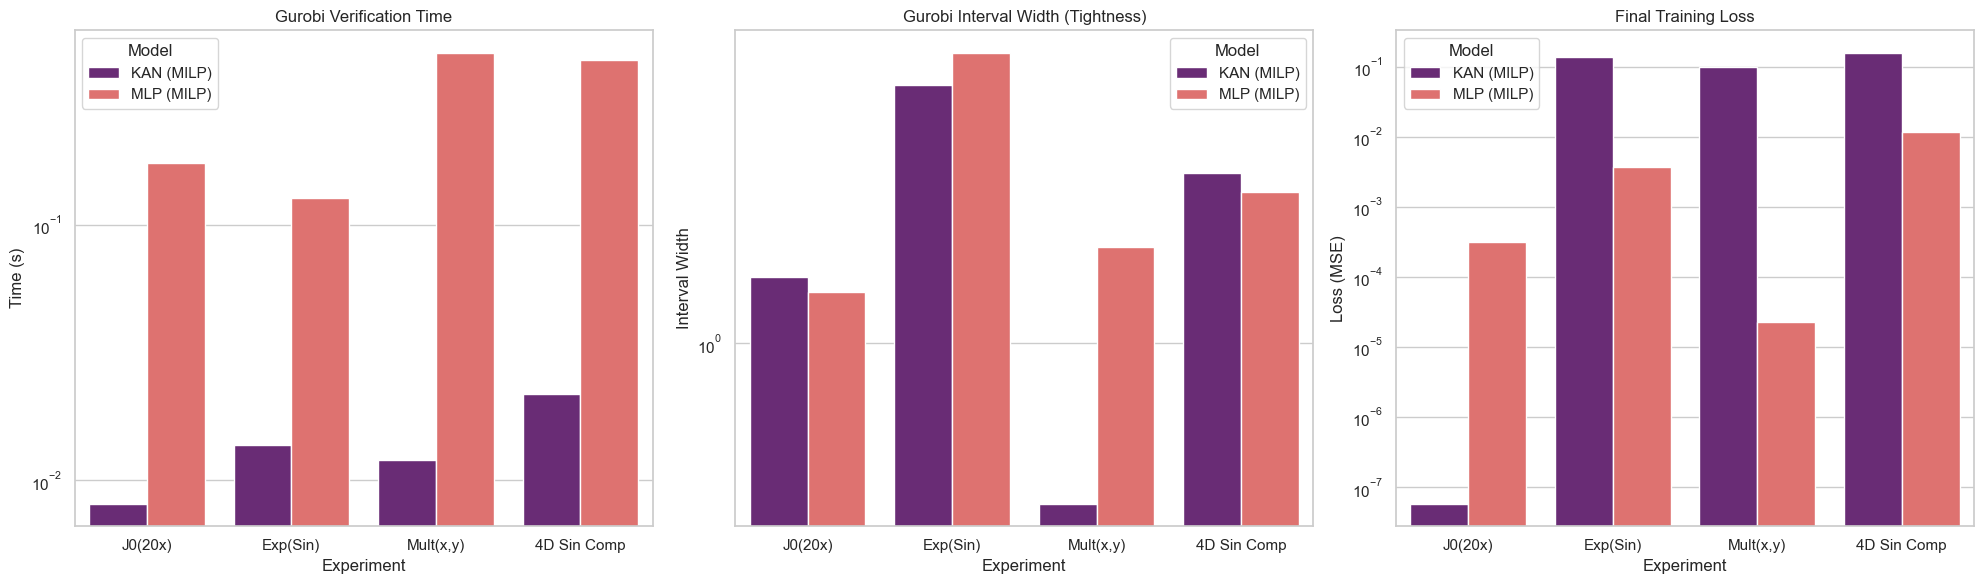


--- Gurobi Verification Summary ---
    Experiment       Model  Time (s)  Interval Width  Loss (MSE)
0      J0(20x)  KAN (MILP)  8.10e-03        1.56e+00    5.85e-08
1      J0(20x)  MLP (MILP)  1.76e-01        1.42e+00    3.12e-04
2     Exp(Sin)  KAN (MILP)  1.37e-02        5.67e+00    1.38e-01
3     Exp(Sin)  MLP (MILP)  1.28e-01        7.05e+00    3.65e-03
4    Mult(x,y)  KAN (MILP)  1.21e-02        3.40e-01    9.75e-02
5    Mult(x,y)  MLP (MILP)  4.73e-01        1.91e+00    2.27e-05
6  4D Sin Comp  KAN (MILP)  2.17e-02        3.14e+00    1.57e-01
7  4D Sin Comp  MLP (MILP)  4.45e-01        2.78e+00    1.16e-02


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. Gurobi Experiment Runner
# ==========================================
def run_gurobi_comparison_and_log():
    gurobi_results = []
    
    # Define the experiments to run
    # Format: (Name, Data_Fn, Input_Dim, Output_Dim, KAN_Hidden, KAN_Params, MLP_Params, MLP_Depth)
    experiments = [
        ("J0(20x)", data_1, 1, 1, [1, 1], 85, 500, 5),
        ("Exp(Sin)", data_2, 2, 1, [2, 1], 70, 600, 3),
        ("Mult(x,y)", data_3, 2, 1, [2, 1], 85, 1000, 4),
        ("4D Sin Comp", data_5, 4, 1, [4, 1], 100, 1000, 4)
    ]

    for name, data_fn, inp_dim, out_dim, k_hidden, k_params, m_params, m_depth in experiments:
        print(f"\n--- Running Gurobi Experiment: {name} ---")
        
        # Initialize and train models (re-using your existing helper functions)
        kan_model = get_optimal_fastkan(k_hidden, k_params)
        mlp_model = get_optimal_mlp(inp_dim, out_dim, m_params, m_depth)
        
        print("Training Models...")
        kan_loss = train_and_return_loss(kan_model, data_fn, steps=2000)
        mlp_loss = train_and_return_loss(mlp_model, data_fn, steps=2000)
        
        # --- KAN Gurobi Verification ---
        print("Verifying KAN (MILP)...")
        k_min, k_max, k_time = verify_kan(kan_model, -1.0, 1.0)
        k_width = k_max[0] - k_min[0]
        
        # --- MLP Gurobi Verification (Big-M MILP) ---
        print("Verifying MLP (MILP)...")
        (m_min, m_max), m_time = verify_mlp(mlp_model, -1.0, 1.0)
        m_width = m_max[0] - m_min[0]

        # Log KAN
        gurobi_results.append({
            "Experiment": name, "Model": "KAN (MILP)", 
            "Time (s)": k_time, "Interval Width": k_width, "Loss (MSE)": kan_loss
        })
        # Log MLP
        gurobi_results.append({
            "Experiment": name, "Model": "MLP (MILP)", 
            "Time (s)": m_time, "Interval Width": m_width, "Loss (MSE)": mlp_loss
        })

    return gurobi_results

# ==========================================
# 2. Execute and Plot (Mirroring Auto-LiRPA Style)
# ==========================================
results_list = run_gurobi_comparison_and_log()
df = pd.DataFrame(results_list)

# Set style to match exactly
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Verification Time (Log Scale)
sns.barplot(data=df, x="Experiment", y="Time (s)", hue="Model", ax=axes[0], palette="magma")
axes[0].set_title("Gurobi Verification Time")
axes[0].set_yscale("log")

# 2. Interval Width (Tightness - Log Scale)
sns.barplot(data=df, x="Experiment", y="Interval Width", hue="Model", ax=axes[1], palette="magma")
axes[1].set_title("Gurobi Interval Width (Tightness)")
axes[1].set_yscale("log")

# 3. Training Loss
sns.barplot(data=df, x="Experiment", y="Loss (MSE)", hue="Model", ax=axes[2], palette="magma")
axes[2].set_title("Final Training Loss")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()

# Display Summary Table
print("\n--- Gurobi Verification Summary ---")
pd.set_option('display.float_format', '{:.2e}'.format)
print(df[["Experiment", "Model", "Time (s)", "Interval Width", "Loss (MSE)"]])

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# Initialize global loader once to avoid overhead in training loop
_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
_dataset = torchvision.datasets.MNIST(root="./data_mnist", train=True, download=True, transform=_transform)
_mnist_loader = DataLoader(_dataset, batch_size=1024, shuffle=True)
_mnist_iter = iter(_mnist_loader)

def data_6():
    global _mnist_iter
    try:
        x, y = next(_mnist_iter)
    except StopIteration:
        _mnist_iter = iter(_mnist_loader)
        x, y = next(_mnist_iter)
    x = x.view(x.size(0), -1)
    y = F.one_hot(y, num_classes=10).float()
    return x, y

kan_6 = get_optimal_fastkan([784, 13, 10], 30000)
mlp_6 = get_optimal_mlp(784, 10, 30000, 3)
print(f"FastKAN Params: {count_params(kan_6)} | MLP Params: {count_params(mlp_6)}")

print("Training FastKAN...")
train(kan_6, data_6, steps=4)
print("Training MLP...")
train(mlp_6, data_6, steps=4)

print("Verifying FastKAN...")
# Only printing Neuron 0 for brevity
k_min, k_max, k_time = verify_kan(kan_6, -0.005, 0.005)
print(f"Result (Neuron 0): [{k_min[0]:.4f}, {k_max[0]:.4f}] in {k_time:.6f}s")

print("Verifying MLP...")
(m_min, m_max), m_time = verify_mlp(mlp_6, -0.005, 0.005)
print(f"Result (Neuron 0): [{m_min[0]:.4f}, {m_max[0]:.4f}] in {m_time:.6f}s")

FastKAN Params: 30966 | MLP Params: 30355
Training FastKAN...
Step 3, Loss: 0.100000
Training MLP...
Step 3, Loss: 0.109173
Verifying FastKAN...
Analyzing Layer 0: 784 inputs -> 13 outputs
Analyzing Layer 1: 13 inputs -> 10 outputs
Optimal allocation found with 242276.0 segments.
Error: Neuron 0 MIN failed (Status 3).
Error: Neuron 0 MAX failed (Status 3).
Error: Neuron 1 MIN failed (Status 3).
Error: Neuron 1 MAX failed (Status 3).
Error: Neuron 2 MIN failed (Status 3).
Error: Neuron 2 MAX failed (Status 3).
Error: Neuron 3 MIN failed (Status 3).
Error: Neuron 3 MAX failed (Status 3).
Error: Neuron 4 MIN failed (Status 3).
Error: Neuron 4 MAX failed (Status 3).
Error: Neuron 5 MIN failed (Status 3).
Error: Neuron 5 MAX failed (Status 3).
Error: Neuron 6 MIN failed (Status 3).
Error: Neuron 6 MAX failed (Status 3).
Error: Neuron 7 MIN failed (Status 3).
Error: Neuron 7 MAX failed (Status 3).
Error: Neuron 8 MIN failed (Status 3).
Error: Neuron 8 MAX failed (Status 3).
Error: Neuron 9 M

# Auto-LIRPA

In [8]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from auto_LiRPA import BoundedModule, BoundedTensor
from auto_LiRPA.perturbations import PerturbationLpNorm

# ==========================================
# 1. Auto-LiRPA Verification Function
# ==========================================
def verify_mlp_autolirpa(model, input_lb, input_ub, device='cpu'):
    """
    Verifies MLP using auto_LiRPA with alpha-CROWN (CROWN-Optimized).
    This provides significantly tighter bounds than IBP by optimizing 
    the linear relaxation slopes.
    """
    start_time = time.time()
    model.eval()
    
    # Handle scalar or vector inputs
    lb_val = float(input_lb) if np.isscalar(input_lb) else input_lb[0]
    ub_val = float(input_ub) if np.isscalar(input_ub) else input_ub[0]
    
    # 1. Define Input Center and Radius (Epsilon)
    center_val = (lb_val + ub_val) / 2.0
    eps_val = (ub_val - lb_val) / 2.0
    
    # Get input dimension from the first layer weights
    first_layer = model[0]
    input_dim = first_layer.weight.shape[1]
    
    # Create a dummy input for graph tracing (Batch Size = 1)
    x_clean = torch.full((1, input_dim), center_val, device=device)
    
    # 2. Wrap model with Auto_LiRPA
    try:
        bounded_model = BoundedModule(model, x_clean, device=device)
    except Exception as e:
        # Fallback if model is already on GPU but device is CPU, etc.
        print(f"AutoLiRPA Init Warning: {e}")
        bounded_model = BoundedModule(model, x_clean)

    # 3. Define the Interval Perturbation (L-infinity norm)
    ptb = PerturbationLpNorm(norm=float("inf"), eps=eps_val)
    bounded_input = BoundedTensor(x_clean, ptb)
    
    # 4. Configure Optimization for Tight Bounds
    # 'CROWN-Optimized' uses gradient descent to optimize verification parameters (alpha).
    solver_options = {
        'optimize_bound_args': {
            'iteration': 100,   # Higher = Tighter bounds, Slower time
            'lr_alpha': 0.1,    # Learning rate for the alpha optimizer
            'enable_beta_crown': True, # Set True for Branch-and-Bound (Exact but slow)
            'pruning_in_iteration': True
        }
    }
    bounded_model.set_bound_opts(solver_options)
    
    # 5. Compute Bounds
    # 'CROWN-Optimized' is the method name for alpha-CROWN
    final_lb, final_ub = bounded_model.compute_bounds(
        x=(bounded_input,), 
        method='CROWN-Optimized' 
    )
    
    elapsed_time = time.time() - start_time
    
    # Convert to numpy and flatten
    return (final_lb.detach().cpu().numpy().flatten(), final_ub.detach().cpu().numpy().flatten()), elapsed_time

# ==========================================
# 2. Training and Experiment Utils
# ==========================================
def train_and_return_loss(model, get_data, steps=8000):
    opt = optim.AdamW(model.parameters(), lr=1e-2)
    loss_fn = nn.MSELoss()
    final_loss = 0.0
    for i in range(steps):
        x, y = get_data()
        loss = loss_fn(model(x), y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        final_loss = loss.item()
    return final_loss

# Global results container
experiment_results = []

def run_experiment_and_log(exp_name, data_fn, input_dim, output_dim, 
                           kan_hidden, kan_params, mlp_params, mlp_depth, 
                           input_lb, input_ub):
    
    print(f"\n--- Running {exp_name} ---")
    
    # --- Setup Models ---
    # Assuming get_optimal_fastkan and get_optimal_mlp are defined in previous cells
    kan_model = get_optimal_fastkan(kan_hidden, kan_params)
    mlp_model = get_optimal_mlp(input_dim, output_dim, mlp_params, mlp_depth)
    
    # --- Train ---
    print("Training KAN...")
    kan_loss = train_and_return_loss(kan_model, data_fn)
    print("Training MLP...")
    mlp_loss = train_and_return_loss(mlp_model, data_fn)
    
    # --- Verify KAN ---
    print("Verifying KAN (Custom Exact)...")
    k_min, k_max, k_time = verify_kan(kan_model, input_lb, input_ub)
    k_width = k_max[0] - k_min[0]
    print(f"  > KAN Width: {k_width:.6f} | Time: {k_time:.4f}s")
    
    # --- Verify MLP (Auto-LiRPA) ---
    print("Verifying MLP (Auto-LiRPA alpha-CROWN)...")
    (m_min, m_max), m_time = verify_mlp_autolirpa(mlp_model, input_lb, input_ub)
    m_width = m_max[0] - m_min[0]
    print(f"  > MLP Width: {m_width:.6f} | Time: {m_time:.4f}s")
    
    # --- Log Data ---
    experiment_results.append({
        "Experiment": exp_name,
        "Model": "KAN",
        "Time (s)": k_time,
        "Interval Width": k_width,
        "Loss (MSE)": kan_loss,
        "Min_Bound": k_min[0],
        "Max_Bound": k_max[0]
    })
    
    experiment_results.append({
        "Experiment": exp_name,
        "Model": "MLP",
        "Time (s)": m_time,
        "Interval Width": m_width,
        "Loss (MSE)": mlp_loss,
        "Min_Bound": m_min[0],
        "Max_Bound": m_max[0]
    })

def plot_verification_results(results_list):
    if not results_list:
        print("No results to plot.")
        return
        
    df = pd.DataFrame(results_list)
    
    # Set style
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # 1. Verification Time
    sns.barplot(
        data=df, x="Experiment", y="Time (s)", hue="Model", 
        ax=axes[0], palette="viridis"
    )
    axes[0].set_title("Verification Time")
    axes[0].set_ylabel("Time (seconds)")
    axes[0].set_yscale("log") 
    
    # 2. Interval Width (Tightness)
    sns.barplot(
        data=df, x="Experiment", y="Interval Width", hue="Model", 
        ax=axes[1], palette="viridis"
    )
    axes[1].set_title("Interval Width")
    axes[1].set_ylabel("Width (Max - Min)")
    axes[1].set_yscale("log") 
    
    # 3. Training Loss
    sns.barplot(
        data=df, x="Experiment", y="Loss (MSE)", hue="Model", 
        ax=axes[2], palette="viridis"
    )
    axes[2].set_title("Final Training Loss")
    axes[2].set_ylabel("MSE Loss")
    axes[2].set_yscale("log") 
    
    plt.tight_layout()
    plt.show()
    
    # Print Table
    print("\n--- Summary Table ---")
    pd.set_option('display.float_format', '{:.2e}'.format)
    print(df[["Experiment", "Model", "Time (s)", "Interval Width", "Loss (MSE)"]])

# ==========================================
# 3. Run Experiments
# ==========================================

# Clear previous results if re-running
experiment_results = []

# Exp 1: J0(20x)
run_experiment_and_log(
    "J0(20x)", data_1, input_dim=1, output_dim=1,
    kan_hidden=[1, 1], kan_params=85, mlp_params=500, mlp_depth=5,
    input_lb=-1.0, input_ub=1.0
)

# Exp 2: Exp(Sin)
run_experiment_and_log(
    "Exp(Sin)", data_2, input_dim=2, output_dim=1,
    kan_hidden=[2, 1], kan_params=70, mlp_params=600, mlp_depth=3,
    input_lb=-1.0, input_ub=1.0
)

# Exp 3: Multiplication
run_experiment_and_log(
    "Mult(x,y)", data_3, input_dim=2, output_dim=1,
    kan_hidden=[2, 1], kan_params=85, mlp_params=1000, mlp_depth=4,
    input_lb=-1.0, input_ub=1.0
)

# Exp 5: 4D Sin
run_experiment_and_log(
    "4D Sin Comp", data_5, input_dim=4, output_dim=1,
    kan_hidden=[4, 1], kan_params=100, mlp_params=1000, mlp_depth=4,
    input_lb=-1.0, input_ub=1.0
)

# Plot
plot_verification_results(experiment_results)


--- Running J0(20x) ---
Training KAN...
Training MLP...
Verifying KAN (Custom Exact)...
Analyzing Layer 0: 1 inputs -> 1 outputs
Optimal allocation found with 14.0 segments.
  > KAN Width: 1.521126 | Time: 0.0105s
Verifying MLP (Auto-LiRPA alpha-CROWN)...


AttributeError: 'BoundedModule' object has no attribute 'split_nodes'

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# Initialize global loader once to avoid overhead in training loop
_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
_dataset = torchvision.datasets.MNIST(root="./data_mnist", train=True, download=True, transform=_transform)
_mnist_loader = DataLoader(_dataset, batch_size=1024, shuffle=True)
_mnist_iter = iter(_mnist_loader)

def data_6():
    global _mnist_iter
    try:
        x, y = next(_mnist_iter)
    except StopIteration:
        _mnist_iter = iter(_mnist_loader)
        x, y = next(_mnist_iter)
    x = x.view(x.size(0), -1)
    y = F.one_hot(y, num_classes=10).float()
    return x, y

kan_6 = get_optimal_fastkan([784, 13, 10], 30000)
mlp_6 = get_optimal_mlp(784, 10, 30000, 3)
print(f"FastKAN Params: {count_params(kan_6)} | MLP Params: {count_params(mlp_6)}")

print("Training FastKAN...")
train(kan_6, data_6, steps=4000)
print("Training MLP...")
train(mlp_6, data_6, steps=4000)

print("Verifying FastKAN...")
# Only printing Neuron 0 for brevity
k_min, k_max, k_time = verify_kan(kan_6, -0.5, 0.5)
print(f"Result (Neuron 0): [{k_min[0]:.4f}, {k_max[0]:.4f}] in {k_time:.6f}s")

print("Verifying MLP...")
(m_min, m_max), m_time = verify_mlp_autolirpa(mlp_6, -0.5, 0.5)
print(f"Result (Neuron 0): [{m_min[0]:.4f}, {m_max[0]:.4f}] in {m_time:.6f}s")

# 100 params vs 100 params

In [26]:
import time
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import random
from auto_LiRPA import BoundedModule, BoundedTensor
from auto_LiRPA.perturbations import PerturbationLpNorm

# 0. Deterministic Seeding for Reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# 1. TIGHTEST MLP Verifier (Beta-CROWN with safety fixes)
def verify_mlp_beta_crown_robust(model, input_lb, input_ub, device='cpu'):
    start_time = time.time()
    model.eval()
    
    lb_val = float(input_lb) if np.isscalar(input_lb) else input_lb[0]
    ub_val = float(input_ub) if np.isscalar(input_ub) else input_ub[0]
    center_val = (lb_val + ub_val) / 2.0
    eps_val = (ub_val - lb_val) / 2.0
    
    first_layer = model[0]
    input_dim = first_layer.weight.shape[1]
    x_clean = torch.full((1, input_dim), center_val, device=device)
    
    # Wrap model
    try:
        bounded_model = BoundedModule(model, x_clean, device=device)
    except:
        bounded_model = BoundedModule(model, x_clean)

    ptb = PerturbationLpNorm(norm=float("inf"), eps=eps_val)
    bounded_input = BoundedTensor(x_clean, ptb)
    
    # Solver Options: Beta-CROWN (Branch & Bound)
    # We remove 'enable_alpha_crown' when using beta to avoid conflicts in some versions
    solver_options = {
        'optimize_bound_args': {
            'iteration': 100,         
            'lr_alpha': 0.1,          
            'enable_beta_crown': True,  # Back to True for tightness
            'pruning_in_iteration': True
        }
    }
    bounded_model.set_bound_opts(solver_options)
    
    # Note: If this still crashes on your specific version, we fall back to alpha-CROWN
    try:
        final_lb, final_ub = bounded_model.compute_bounds(
            x=(bounded_input,), 
            method='CROWN-Optimized' 
        )
    except AttributeError:
        print("   (Beta-CROWN failed, falling back to Alpha-CROWN...)")
        solver_options['optimize_bound_args']['enable_beta_crown'] = False
        bounded_model.set_bound_opts(solver_options)
        final_lb, final_ub = bounded_model.compute_bounds(
            x=(bounded_input,), 
            method='CROWN-Optimized' 
        )

    return (final_lb.detach().cpu().numpy().flatten(), final_ub.detach().cpu().numpy().flatten()), time.time() - start_time

# --- EXPERIMENT START ---
set_seed(42) # <--- FIXED SEED

print("--- Setup: 100-Parameter Constraint Experiment (Seeded) ---")

# Define constraints
TARGET_PARAMS = 100
INPUT_DIM = 1
OUTPUT_DIM = 1
INPUT_LB = -0.5  
INPUT_UB = 0.5

# Instantiate models
kan_100 = get_optimal_fastkan([INPUT_DIM, OUTPUT_DIM], TARGET_PARAMS)
mlp_100 = get_optimal_mlp(INPUT_DIM, OUTPUT_DIM, TARGET_PARAMS, depth=3)

print(f"Model 1: FastKAN -> {count_params(kan_100)} params")
print(f"Model 2: MLP     -> {count_params(mlp_100)} params")

# Train
print("\n--- Training Models (2000 steps) ---")
k_loss = train_and_return_loss(kan_100, data_1, steps=2000)
m_loss = train_and_return_loss(mlp_100, data_1, steps=2000)
print(f"KAN Loss: {k_loss:.2e} | MLP Loss: {m_loss:.2e}")

# Verification Phase
print("\n--- Verification Phase ---")
results = []

# A. KAN via Gurobi
print("1. Verifying KAN (Gurobi MILP)...")
k_min, k_max, k_time = verify_kan(kan_100, INPUT_LB, INPUT_UB)
k_width = k_max[0] - k_min[0]
results.append({
    "Model": "KAN", "Method": "Gurobi (Exact)",
    "Time (s)": k_time, "Width": k_width, "LB": k_min[0], "UB": k_max[0]
})

# B. MLP via Gurobi
print("2. Verifying MLP (Gurobi MILP)...")
(m_g_min, m_g_max), m_g_time = verify_mlp(mlp_100, INPUT_LB, INPUT_UB)
m_g_width = m_g_max[0] - m_g_min[0]
results.append({
    "Model": "MLP", "Method": "Gurobi (Exact)",
    "Time (s)": m_g_time, "Width": m_g_width, "LB": m_g_min[0], "UB": m_g_max[0]
})

# C. MLP via Beta-CROWN
print("3. Verifying MLP (Auto-LiRPA Beta-CROWN)...")
(m_l_min, m_l_max), m_l_time = verify_mlp_beta_crown_robust(mlp_100, INPUT_LB, INPUT_UB)
m_l_width = m_l_max[0] - m_l_min[0]
results.append({
    "Model": "MLP", "Method": "Beta-CROWN",
    "Time (s)": m_l_time, "Width": m_l_width, "LB": m_l_min[0], "UB": m_l_max[0]
})

# Detailed Printout
print("\n" + "="*80)
print(f"{'MODEL':<6} | {'METHOD':<20} | {'TIME (s)':<10} | {'WIDTH':<10} | {'BOUNDS (LB, UB)':<20}")
print("-" * 80)
for res in results:
    print(f"{res['Model']:<6} | {res['Method']:<20} | {res['Time (s)']:<10.4f} | {res['Width']:<10.4f} | [{res['LB']:.4f}, {res['UB']:.4f}]")
print("="*80 + "\n")

# Analysis
print("--- Comparative Analysis ---")
kan_w = results[0]['Width']
mlp_g_w = results[1]['Width']
mlp_c_w = results[2]['Width']

print(f"KAN vs MLP (Gurobi) Tightness: {mlp_g_w / kan_w:.2f}x ratio (KAN is {'tighter' if kan_w < mlp_g_w else 'looser'})")
print(f"KAN vs MLP (CROWN)  Tightness: {mlp_c_w / kan_w:.2f}x ratio (KAN is {'tighter' if kan_w < mlp_c_w else 'looser'})")
print(f"KAN vs MLP (Gurobi) Speed:     {results[1]['Time (s)'] / results[0]['Time (s)']:.2f}x speedup")

--- Setup: 100-Parameter Constraint Experiment (Seeded) ---
Model 1: FastKAN -> 100 params
Model 2: MLP     -> 103 params

--- Training Models (2000 steps) ---
KAN Loss: 3.76e-08 | MLP Loss: 6.28e-02

--- Verification Phase ---
1. Verifying KAN (Gurobi MILP)...
Analyzing Layer 0: 1 inputs -> 1 outputs
Optimal allocation found with 19.0 segments.
2. Verifying MLP (Gurobi MILP)...
Set parameter TimeLimit to value 10000
INFO     10:16:02     [3479689757.py:54] Set parameter TimeLimit to value 10000
3. Verifying MLP (Auto-LiRPA Beta-CROWN)...
   (Beta-CROWN failed, falling back to Alpha-CROWN...)
Early stop at 30th iter due to 10 iterations no improvement!
Early stop at 41th iter due to 10 iterations no improvement!

MODEL  | METHOD               | TIME (s)   | WIDTH      | BOUNDS (LB, UB)     
--------------------------------------------------------------------------------
KAN    | Gurobi (Exact)       | 0.0061     | 1.4744     | [-0.4255, 1.0490]
MLP    | Gurobi (Exact)       | 0.0069   